<a href="https://colab.research.google.com/github/SevdeColak/YapayZeka_calismalarim/blob/main/Students'SocialMediaAddiction_DataScience.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Students Social Media Addiction Analysis

In this notebook, we analyze the relationship between students' social media usage, addiction, sleep patterns, mental health, and academic performance.  
Additionally, we build a simple machine learning model to predict whether a student is addicted or not.


# 📌 1. Import Libraries

In [ ]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# 📌 2. Load Dataset

In [ ]:

df = pd.read_csv('StudentsSocialMediaAddiction.csv')
df.head()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


# 📌 3. Dataset Info

In [ ]:

df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    705 non-null    int64  
 1   Age                           705 non-null    int64  
 2   Gender                        705 non-null    object 
 3   Academic_Level                705 non-null    object 
 4   Country                       705 non-null    object 
 5   Avg_Daily_Usage_Hours         705 non-null    float64
 6   Most_Used_Platform            705 non-null    object 
 7   Affects_Academic_Performance  705 non-null    object 
 8   Sleep_Hours_Per_Night         705 non-null    float64
 9   Mental_Health_Score           705 non-null    int64  
 10  Relationship_Status           705 non-null    object 
 11  Conflicts_Over_Social_Media   705 non-null    int64  
 12  Addicted_Score                705 non-null    int64  
dtypes: fl

,0
Student_ID,0
Age,0
Gender,0
Academic_Level,0
Country,0
Avg_Daily_Usage_Hours,0
Most_Used_Platform,0
Affects_Academic_Performance,0
Sleep_Hours_Per_Night,0
Mental_Health_Score,0


# 📌 4. Exploratory Data Analysis (EDA)

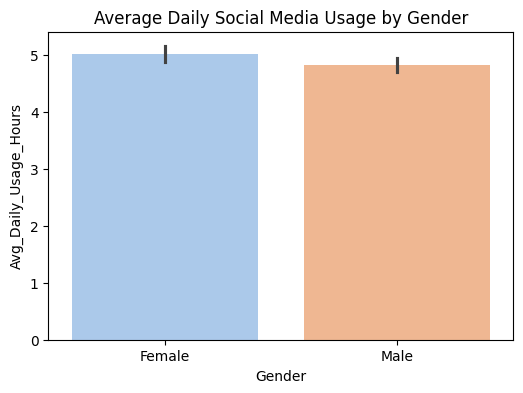

In [ ]:
# 🎯 Average Daily Usage by Gender
plt.figure(figsize=(6,4))
sns.barplot(data=df, x="Gender", y="Avg_Daily_Usage_Hours", palette="pastel")
plt.title("Average Daily Social Media Usage by Gender")
plt.show()

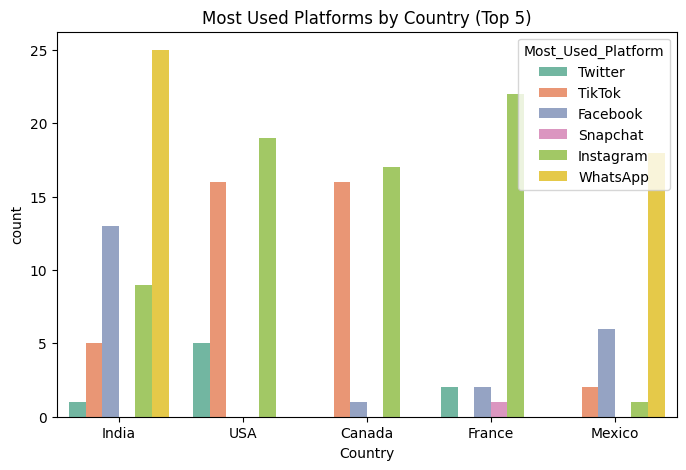

In [ ]:
# 🌍 Most Used Platforms by Country (Top 5)
top_countries = df['Country'].value_counts().nlargest(5).index
top_df = df[df['Country'].isin(top_countries)]

plt.figure(figsize=(8,5))
sns.countplot(data=top_df, x="Country", hue="Most_Used_Platform", palette="Set2")
plt.title("Most Used Platforms by Country (Top 5)")
plt.show()

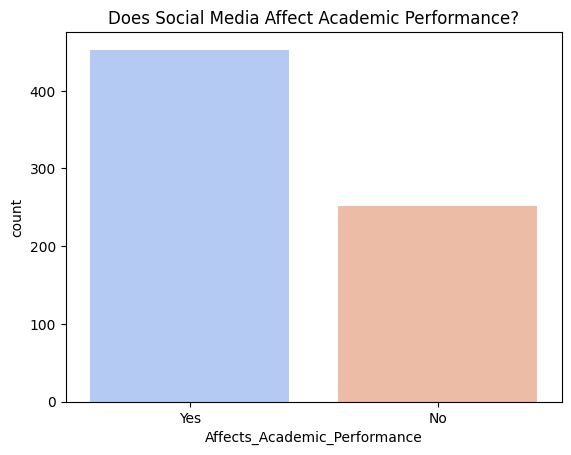

In [ ]:
# 📚 Impact on Academic Performance
sns.countplot(data=df, x="Affects_Academic_Performance", palette="coolwarm")
plt.title("Does Social Media Affect Academic Performance?")
plt.show()

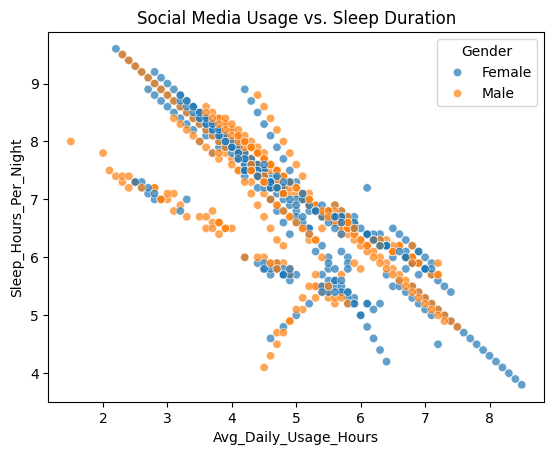

In [ ]:
# 😴 Daily Usage vs. Sleep Hours
sns.scatterplot(data=df, x="Avg_Daily_Usage_Hours", y="Sleep_Hours_Per_Night", hue="Gender", alpha=0.7)
plt.title("Social Media Usage vs. Sleep Duration")
plt.show()

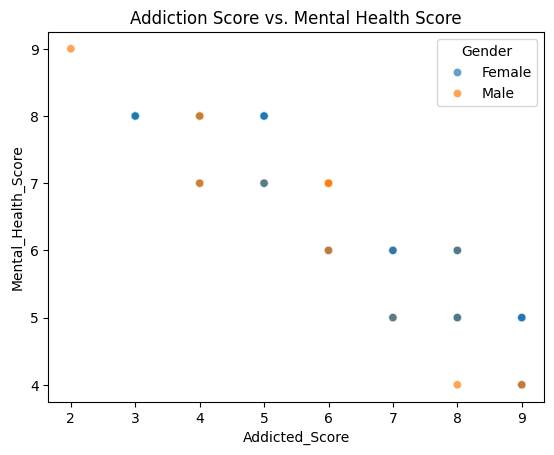

In [ ]:
# 🧠 Addiction Score vs. Mental Health
sns.scatterplot(data=df, x="Addicted_Score", y="Mental_Health_Score", hue="Gender", alpha=0.7)
plt.title("Addiction Score vs. Mental Health Score")
plt.show()

# 📌 5. Correlation Analysis

In [ ]:
pearson = df["Addicted_Score"].corr(df["Mental_Health_Score"], method="pearson")
spearman = df["Addicted_Score"].corr(df["Mental_Health_Score"], method="spearman")
kendall = df["Addicted_Score"].corr(df["Mental_Health_Score"], method="kendall")

print("Pearson:", pearson)
print("Spearman:", spearman)
print("Kendall:", kendall)

Pearson: -0.9450506757277399
Spearman: -0.9497060751671579
Kendall: -0.906417918807041


# 📌 6. Machine Learning: Addiction Prediction

In [ ]:
# 🎯 Define addiction: Addicted_Score >= 7 → "Addicted"
df["Target"] = (df["Addicted_Score"] >= 7).astype(int)

# Encode categorical features
encoder = LabelEncoder()
for col in ["Gender", "Academic_Level", "Country", "Most_Used_Platform", "Affects_Academic_Performance", "Relationship_Status"]:
    df[col] = encoder.fit_transform(df[col])

# Features and target
X = df.drop(columns=["Student_ID","Addicted_Score","Target"])
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

              precision    recall  f1-score   support

           0       1.00      0.94      0.97        62
           1       0.95      1.00      0.98        79

    accuracy                           0.97       141
   macro avg       0.98      0.97      0.97       141
weighted avg       0.97      0.97      0.97       141



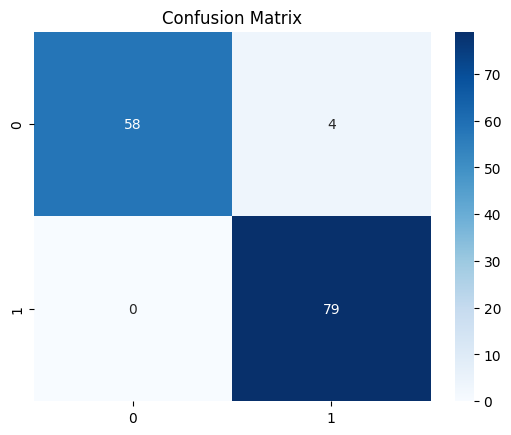

In [ ]:
# 📌 Build Model

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

## 📌 Key Findings & Conclusion
1. **Strong Negative Correlation:**  
   There is a very strong negative correlation between **Addicted Score** and **Mental Health Score**  
   (Pearson = -0.94, Spearman = -0.95).  
   → The higher the addiction, the lower the mental well-being.

2. **Sleep Deprivation Link:**  
   Students with higher social media usage tend to sleep less, which is also associated with lower academic performance.

3. **Conflicts Over Social Media:**  
   Students reporting frequent conflicts due to social media usage generally have higher addiction levels.

4. **Model Performance:**  
   - Logistic Regression achieved **97% accuracy**.  
   - The model detected all addicted students (**Recall = 1.00 for Class 1**)  
   - Small trade-off: a few non-addicted students were incorrectly classified as addicted.  

5. **Practical Implication:**  
   This model can be used as a **screening tool** to identify at-risk students and provide early intervention.